In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
heatwaves = pd.read_csv("../data/yearly_statistics.csv")
landsat = pd.read_csv("../data/landsat_shanghai/shanghai_is_ndbi_stats.csv")

In [3]:
landsat.head()

,high_IS_area_km2,high_IS_frac,mean_IS,p90_IS,year,high_NDBI_area_km2,high_NDBI_frac,mean_NDBI,p90_NDBI,high_NDBI_masked_area_km2,high_NDBI_masked_frac,mean_NDBI_masked,p90_NDBI_masked
0,0.012250,0.000004,0.274870,0.416033,1990,0.351424,0.118232,-0.394710,-0.175510,0.351424,0.118232,-0.270263,-0.128979
1,0.004600,0.000002,0.265864,0.392444,1991,0.300184,0.070197,-0.413216,-0.136775,0.300184,0.070197,-0.233739,-0.097715
2,1.078307,0.000270,0.348369,0.494127,1992,0.392331,0.160578,-0.369584,-0.121123,0.392331,0.160578,-0.222673,-0.089883
3,0.033892,0.000010,0.314812,0.419873,1993,0.310957,0.027124,-0.329313,-0.066393,0.302557,0.026399,-0.141172,-0.035230
4,0.210625,0.000053,0.352094,0.486320,1994,0.416704,0.026590,-0.360731,-0.082065,0.416704,0.026591,-0.195003,-0.043091


In [4]:
heatwaves.head()

,Unnamed: 0,year,num_events,max_duration,med_duration,avg_intensity,max_intensity
0,0,1991,2,3,3.0,1.388710,2.635504
1,1,1992,4,5,3.5,2.117359,6.515036
2,2,1993,4,3,3.0,1.930759,8.393950
3,3,1994,6,4,3.0,1.087174,2.678678
4,4,1995,4,4,3.5,1.442981,4.774977


In [5]:
# Remove unused column
heatwaves.drop(columns="Unnamed: 0",inplace=True)

In [6]:
# Merge both datasets across time dimension
data = pd.merge(heatwaves,landsat, on="year", how="outer")

In [7]:
data.head()

,year,num_events,max_duration,med_duration,avg_intensity,max_intensity,high_IS_area_km2,high_IS_frac,mean_IS,p90_IS,high_NDBI_area_km2,high_NDBI_frac,mean_NDBI,p90_NDBI,high_NDBI_masked_area_km2,high_NDBI_masked_frac,mean_NDBI_masked,p90_NDBI_masked
0,1991,2.0,3.0,3.0,1.388710,2.635504,0.004600,1.540372e-06,0.265864,0.392444,0.300184,0.070197,-0.413216,-0.136775,0.300184,0.070197,-0.233739,-0.097715
1,1992,4.0,5.0,3.5,2.117359,6.515036,1.078307,2.704117e-04,0.348369,0.494127,0.392331,0.160578,-0.369584,-0.121123,0.392331,0.160578,-0.222673,-0.089883
2,1993,4.0,3.0,3.0,1.930759,8.393950,0.033892,9.527869e-06,0.314812,0.419873,0.310957,0.027124,-0.329313,-0.066393,0.302557,0.026399,-0.141172,-0.035230
3,1994,6.0,4.0,3.0,1.087174,2.678678,0.210625,5.280722e-05,0.352094,0.486320,0.416704,0.026590,-0.360731,-0.082065,0.416704,0.026591,-0.195003,-0.043091
4,1995,4.0,4.0,3.5,1.442981,4.774977,0.000763,2.379339e-07,0.281693,0.427785,0.269117,0.039121,-0.417150,-0.136793,0.269117,0.039121,-0.250304,-0.089868


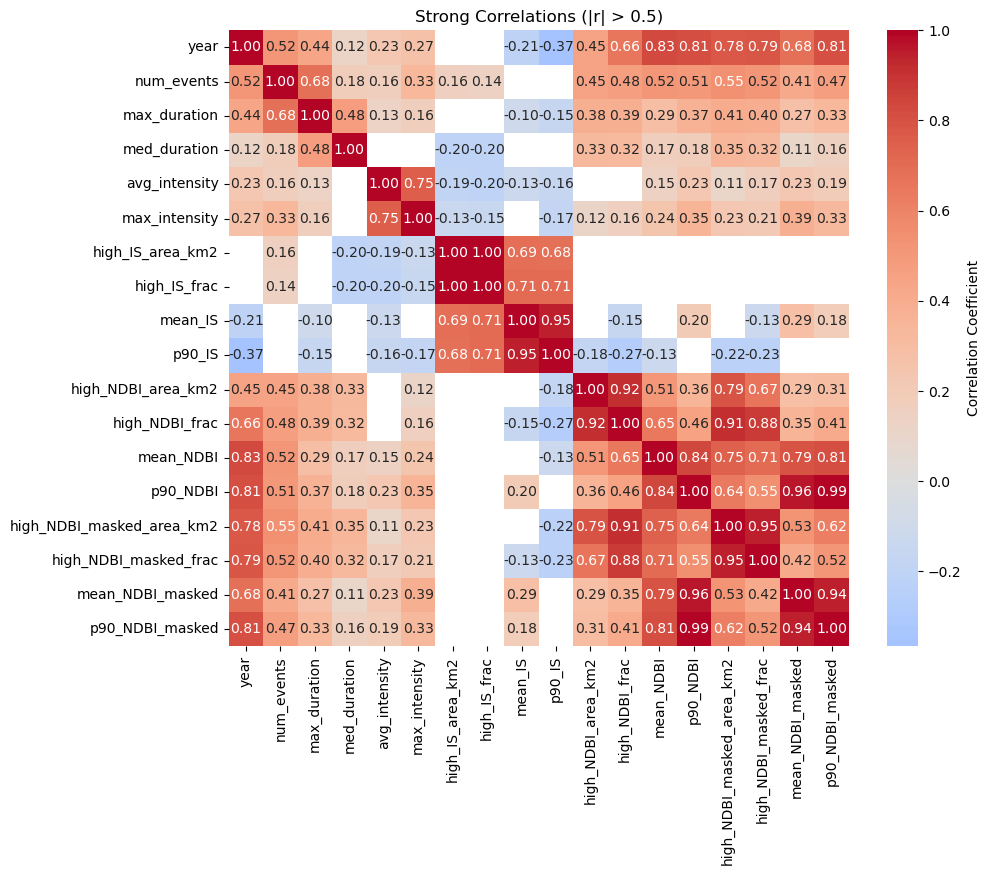

In [9]:
# Heatmap
# Initial screening to get an overview over relationship between variables
# Show only correlations above a threshold
corr = data.corr()
corr_filtered = corr.where(np.abs(corr) > 0.1)  # Only show correlations > 0.5

plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Strong Correlations (|r| > 0.5)')
plt.show()

In [19]:
# Drop na values in data - i.e. year 1990
data=data.dropna()

In [28]:
# Run correlations - Pearson (linear correlation) & Spearman (for non normally distributed data)
%pip install scipy  
from scipy.stats import pearsonr, spearmanr

## for p90_IS variable (>=90th percentile of impervious surface variable (calculated from Landsat data))
# Pearson correlation (linear relationships)
corr_coef, p_value = pearsonr(data['avg_intensity'], data['p90_IS'])
print(f"Pearson correlation: {corr_coef:.3f}")
print(f"P-value: {p_value:.3f}")

# Spearman correlation (monotonic relationships)
corr_coef, p_value = spearmanr(data['avg_intensity'], data['p90_IS'])
print(f"Spearman correlation: {corr_coef:.3f}")
print(f"P-value: {p_value:.3f}")


## for p90_NDBI variable (>=90 pe

# Pearson correlation (linear relationships)
corr_coef, p_value = pearsonr(data['avg_intensity'], data['p90_NDBI'])
print(f"Pearson correlation: {corr_coef:.3f}")
print(f"P-value: {p_value:.3f}")

# Spearman correlation (monotonic relationships)
corr_coef, p_value = spearmanr(data['avg_intensity'], data['p90_NDBI'])
print(f"Spearman correlation: {corr_coef:.3f}")
print(f"P-value: {p_value:.3f}")


Note: you may need to restart the kernel to use updated packages.
Pearson correlation: -0.160
P-value: 0.367
Spearman correlation: -0.154
P-value: 0.384
Note: you may need to restart the kernel to use updated packages.
Pearson correlation: 0.231
P-value: 0.188
Spearman correlation: 0.181
P-value: 0.305


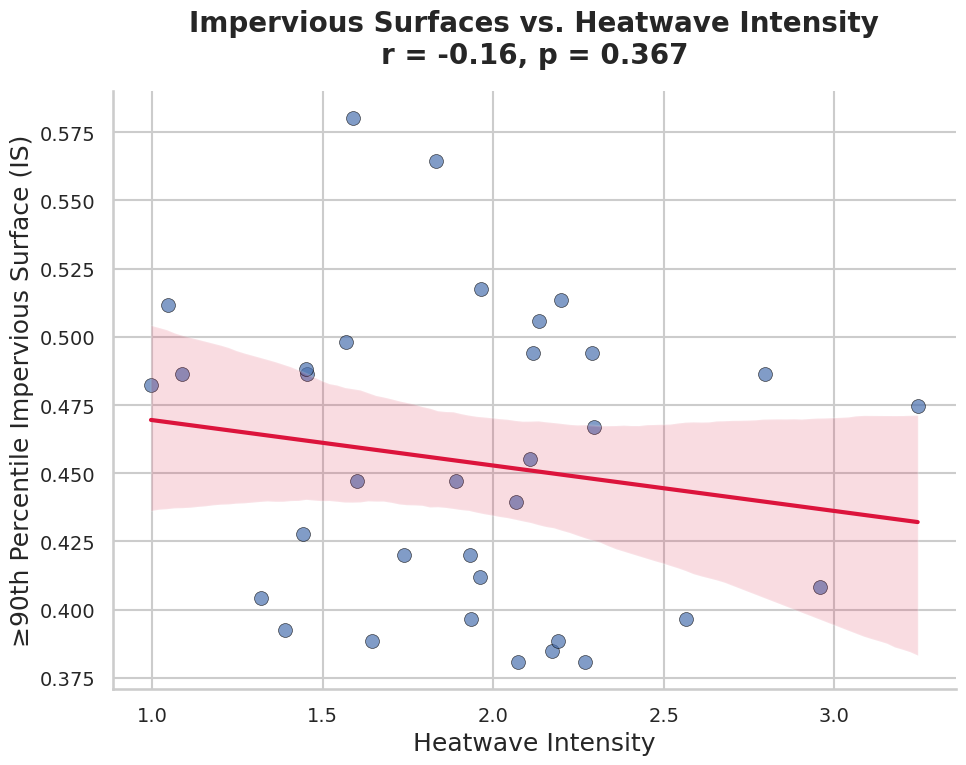

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate correlation
correlation, p_value = pearsonr(data['avg_intensity'], data['p90_IS'])

# Set seaborn style for presentations
sns.set(style='whitegrid', context='talk')

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=data,
    x='avg_intensity',
    y='p90_IS',
    alpha=0.7,
    s=100,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Regression line
sns.regplot(
    data=data,
    x='avg_intensity',
    y='p90_IS',
    scatter=False,
    color='crimson',
    line_kws={'linewidth': 3},
    ax=ax
)

# Add title and axis labels
ax.set_title(
    f'Impervious Surfaces vs. Heatwave Intensity\nr = {correlation:.2f}, p = {p_value:.3f}',
    fontsize=20,
    weight='bold',
    pad=20
)
ax.set_xlabel('Heatwave Intensity', fontsize=18)
ax.set_ylabel('≥90th Percentile Impervious Surface (IS)', fontsize=18)

# Format ticks
ax.tick_params(axis='both', labelsize=14)

# Clean borders and layout
sns.despine()
plt.tight_layout()

# Save high-res figure for slides or publication
fig.savefig('IS_vs_Heatwave_Intensity.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


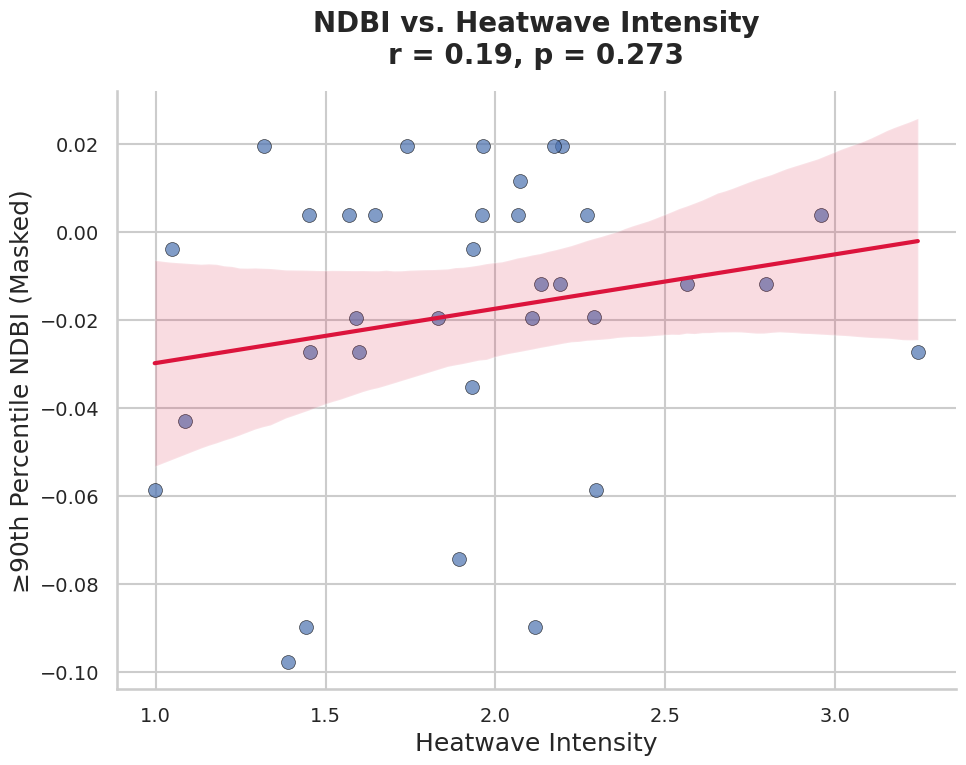

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate correlation
correlation, p_value = pearsonr(data['avg_intensity'], data['p90_NDBI_masked'])

# Set seaborn style for clean visuals
sns.set(style='whitegrid', context='talk')

# Create the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=data,
    x='avg_intensity',
    y='p90_NDBI_masked',
    alpha=0.7,
    s=100,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Regression line
sns.regplot(
    data=data,
    x='avg_intensity',
    y='p90_NDBI_masked',
    scatter=False,
    color='crimson',
    line_kws={'linewidth': 3},
    ax=ax
)

# Titles and labels
ax.set_title(
    f'NDBI vs. Heatwave Intensity\nr = {correlation:.2f}, p = {p_value:.3f}',
    fontsize=20,
    weight='bold',
    pad=20
)
ax.set_xlabel('Heatwave Intensity', fontsize=18)
ax.set_ylabel('≥90th Percentile NDBI (Masked)', fontsize=18)

# Tick formatting
ax.tick_params(axis='both', labelsize=14)

# Clean and layout
sns.despine()
plt.tight_layout()

# Save high-res version
fig.savefig('NDBI_vs_Heatwave_Intensity.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [36]:
data_filtered=data[["avg_intensity", "num_event","mean_NDBI_masked","p90_NDBI_masked ","high_NDBI_masked_frac"]]

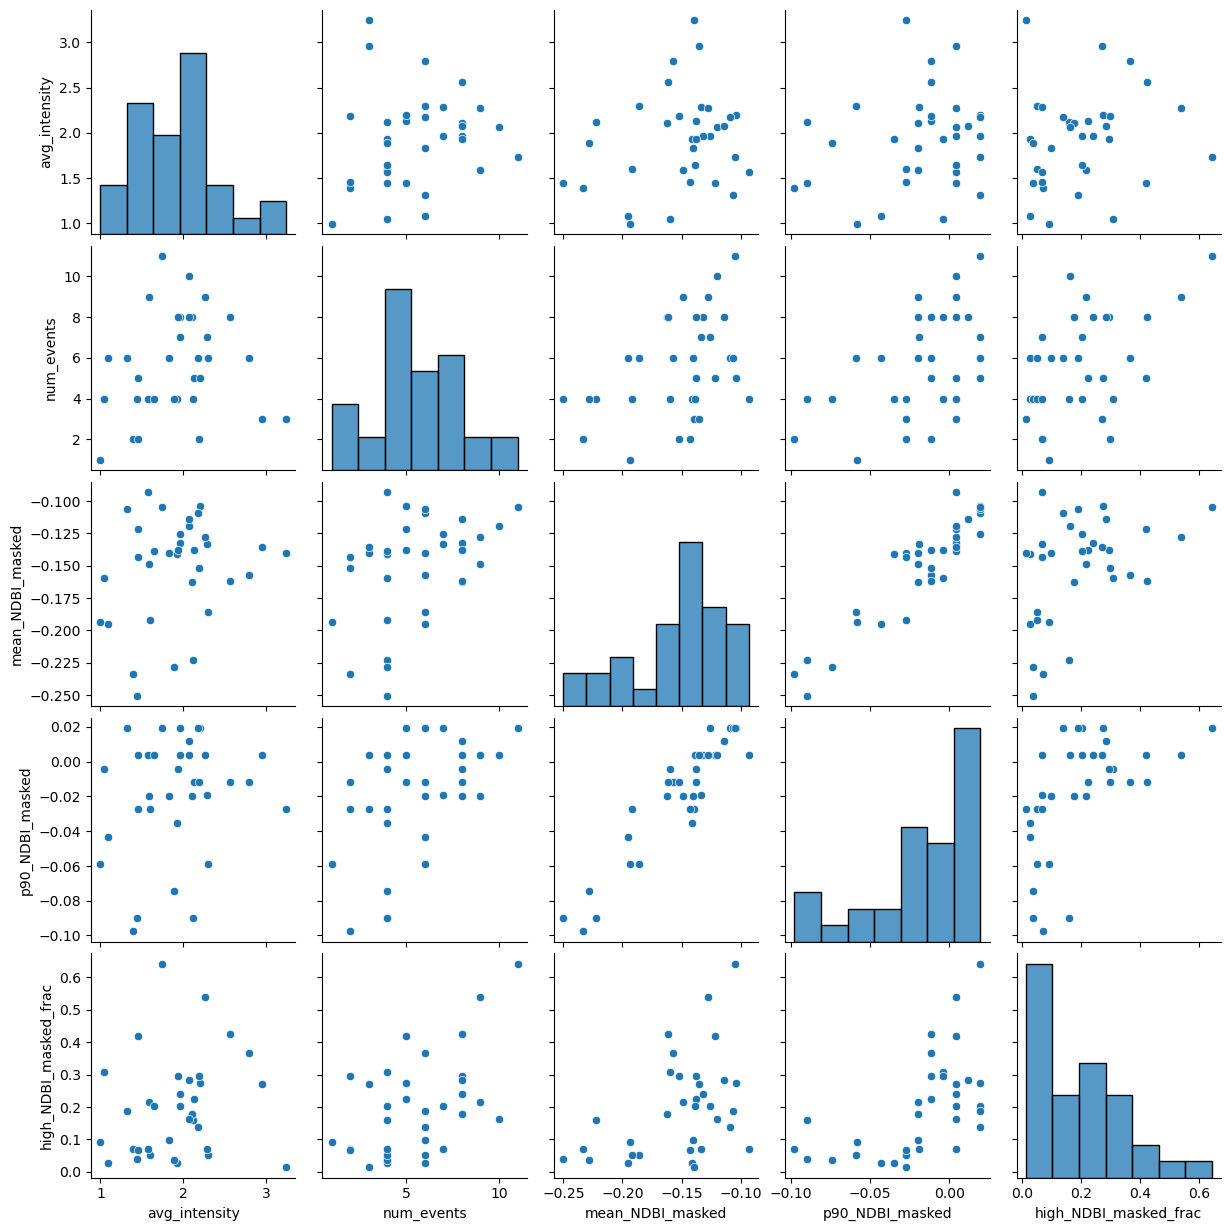

In [37]:
sns.pairplot(data_filtered)

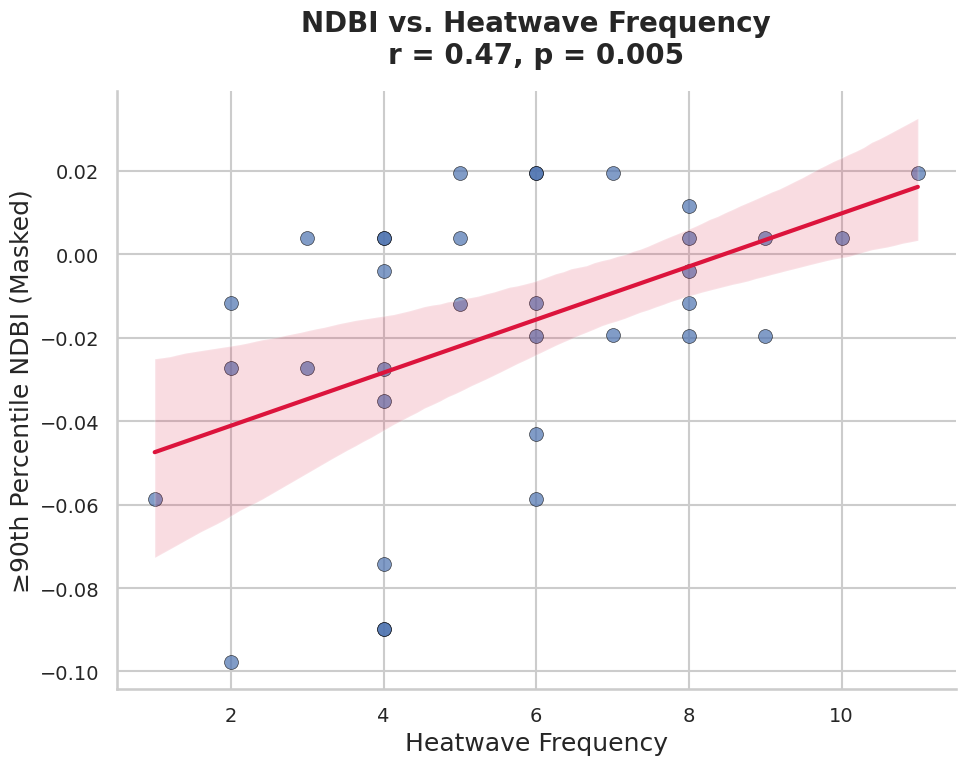

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate correlation
correlation, p_value = pearsonr(data['num_events'], data['p90_NDBI_masked'])

# Set seaborn style for clean visuals
sns.set(style='whitegrid', context='talk')  # 'talk' is good for presentations

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=data,
    x='num_events',
    y='p90_NDBI_masked',
    alpha=0.7,
    s=100,                  # Larger markers
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Regression line
sns.regplot(
    data=data,
    x='num_events',
    y='p90_NDBI_masked',
    scatter=False,
    color='crimson',
    line_kws={'linewidth': 3},
    ax=ax
)

# Add titles and labels
ax.set_title(
    f'NDBI vs. Heatwave Frequency\nr = {correlation:.2f}, p = {p_value:.3f}',
    fontsize=20,
    weight='bold',
    pad=20
)
ax.set_xlabel('Heatwave Frequency', fontsize=18)
ax.set_ylabel('≥90th Percentile NDBI (Masked)', fontsize=18)

# Tick label sizes
ax.tick_params(axis='both', labelsize=14)

# Optional: clean spines
sns.despine()

# Tight layout
plt.tight_layout()

# Save the figure (for slides, transparent background is nice)
fig.savefig('NDBI_Frequency.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()


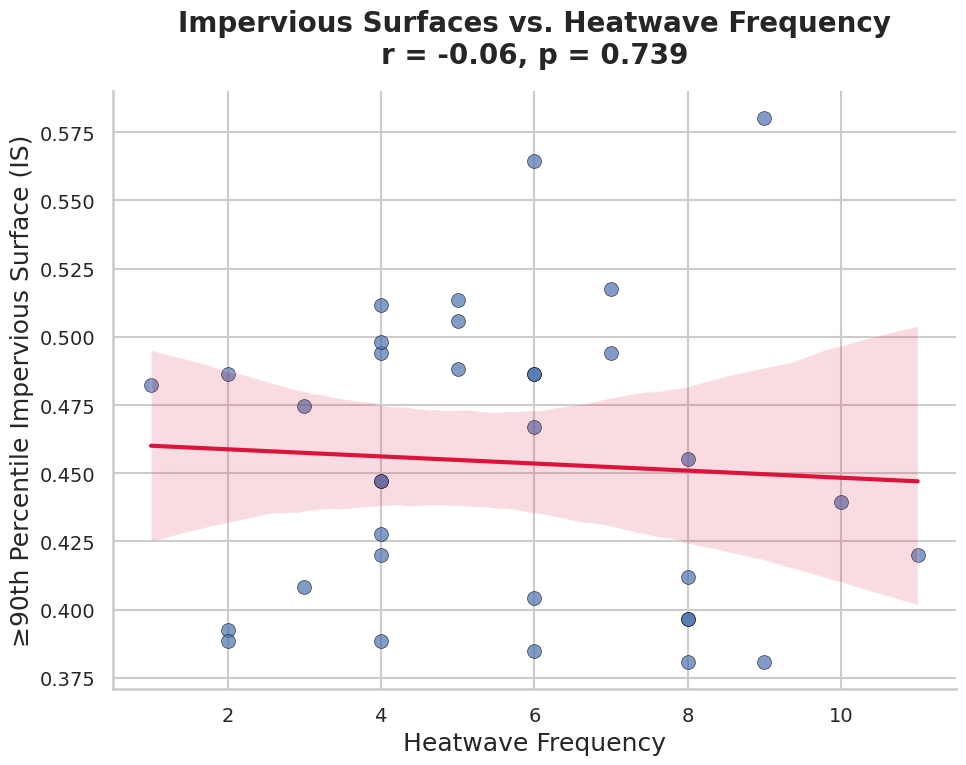

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate correlation
correlation, p_value = pearsonr(data['num_events'], data['p90_IS'])

# Set seaborn style for clean visuals
sns.set(style='whitegrid', context='talk')

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=data,
    x='num_events',
    y='p90_IS',
    alpha=0.7,
    s=100,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Regression line
sns.regplot(
    data=data,
    x='num_events',
    y='p90_IS',
    scatter=False,
    color='crimson',
    line_kws={'linewidth': 3},
    ax=ax
)

# Add titles and labels
ax.set_title(
    f'Impervious Surfaces vs. Heatwave Frequency\nr = {correlation:.2f}, p = {p_value:.3f}',
    fontsize=20,
    weight='bold',
    pad=20
)
ax.set_xlabel('Heatwave Frequency', fontsize=18)
ax.set_ylabel('≥90th Percentile Impervious Surface (IS)', fontsize=18)

# Tick label sizes
ax.tick_params(axis='both', labelsize=14)

# Optional: clean spines
sns.despine()

# Tight layout
plt.tight_layout()

# Save the figure
fig.savefig('IS_Heatwave_Frequency.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()
